<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_2_optimizacion.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_2_optimizacion.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_2_optimizacion.ipynb)

# SI7011 · Sesión 02 · 2. Optimización
**Juan David Martínez Vargas · Universidad EAFIT**

| Sección | Lo que cambia | Qué mirar |
|---|---|---|
| 1 | SGD con $\eta$ bajo, bueno y alto | lento, bien, diverge |
| 2 | momentum | el paso efectivo $\eta/(1-\beta)$ |
| 3 | Adam | una tasa por parámetro |
| 4 | tamaño de lote | pasos por época, tiempo y ruido |
| 5 | warmup + coseno | un $\eta$ que cambia durante el entrenamiento |
| 6 | norma del gradiente y clipping | rescatar un entrenamiento que diverge |

Corre en CPU en 1–2 minutos (Colab, Kaggle, Lightning o local).

In [1]:
import copy, math, time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
from torch import nn
from torchvision import datasets

torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
int_epochs = lambda: plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## Datos: Fashion-MNIST como vectores
Son los mismos datos en los cuatro notebooks de la sesión. Cada imagen de 28×28 se aplana en un vector de 784 valores. Se usan 10 000 ejemplos de entrenamiento, 10 000 de validación (tomados del resto del conjunto de entrenamiento) y el conjunto de prueba oficial. El escalado se calcula **solo** con entrenamiento.

In [2]:
train_set = datasets.FashionMNIST('data', train=True, download=True)
test_set = datasets.FashionMNIST('data', train=False, download=True)
CLASSES = train_set.classes

# imagen 28×28 → vector x ∈ ℝ⁷⁸⁴ con píxeles en [0, 1]
X = train_set.data.reshape(-1, 784).float() / 255
y = train_set.targets  # y ∈ {0, …, 9}: C = 10 clases
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(0))
# entrenamiento: con estos ejemplos se calcula ∇J
X_train, y_train = X[perm[:10_000]], y[perm[:10_000]]
X_val, y_val = X[perm[50_000:]], y[perm[50_000:]]  # validación: J_val, para comparar decisiones
# prueba: se usa una sola vez, al final
X_test, y_test = test_set.data.reshape(-1, 784).float() / 255, test_set.targets

# Estandarizar deja las entradas con media 0 y varianza 1. Las fórmulas de inicialización
# suponen esa escala: Var(z_1) = n_in · Var(W_1) · E[a_0²] con a_0 = x.
mu, sd = X_train.mean(), X_train.std()          # estadísticas solo de entrenamiento
X_train, X_val, X_test = [(t - mu) / sd for t in (X_train, X_val, X_test)]
X_train.shape, X_val.shape, X_test.shape

(torch.Size([10000, 784]), torch.Size([10000, 784]), torch.Size([10000, 784]))

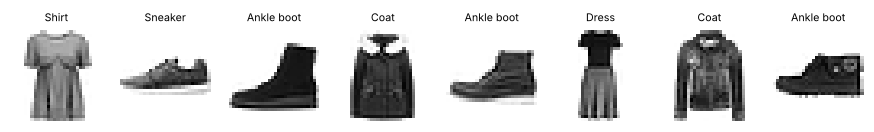

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, train_set.data[perm[:8]], train_set.targets[perm[:8]]):
    ax.imshow(img, cmap='gray_r'); ax.set_title(CLASSES[lab], fontsize=7); ax.axis('off')
plt.show()

## Herramientas: entrenar, evaluar y graficar
Es el mismo loop de la sesión 01 y se define una sola vez. Lo que cambia en cada sección es el **modelo** o el **optimizador**.

In [4]:
# L_i = −log softmax(f_θ(x_i))_{y_i}; recibe logits y aplica log_softmax por dentro
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, opt, batch_size=128):
    model.train()  # modo entrenamiento: Dropout activo, BatchNorm con estadísticas del lote
    perm = torch.randperm(len(X_train))  # orden nuevo en cada época → mini-lotes 𝓑_t distintos
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]  # índices del mini-lote 𝓑_t
        loss = loss_fn(model(X_train[b]), y_train[b])  # J_𝓑(θ) = (1/|𝓑|) Σ_{i∈𝓑} L_i(θ)
        # borrar g anterior · g_t = ∇_θ J_𝓑 (backprop) · θ ← regla del optimizador
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)  # promedio de la época ≈ J sobre entrenamiento
    return total / len(X_train)

@torch.no_grad()  # sin grafo: al evaluar no hay backward
def evaluate(model, X, y):
    model.eval()  # modo evaluación: Dropout apagado, BatchNorm con promedios móviles
    logits = model(X)
    # J_val y accuracy; la clase predicha es argmax de los logits (softmax no cambia el orden)
    return loss_fn(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

In [5]:
def fit(model, opt, epochs=10, batch_size=128):
    hist = {'loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt, batch_size))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_loss {val_loss:.3f} · val_acc {val_acc:.3f} · {time.time() - t0:.1f} s")
    return hist

def plot_curves(hists, key='loss', title='', logy=False):
    for name, h in hists.items():
        plt.plot(range(1, len(h[key]) + 1), h[key], label=name)
    if logy: plt.yscale('log')
    plt.xlabel('época'); plt.ylabel(key); plt.title(title); plt.legend(); int_epochs(); plt.show()

## El modelo fijo de este notebook
Cuatro capas ocultas de 256 unidades, ReLU e inicialización He (notebook 1). La arquitectura **no cambia** en todo el notebook; lo único que cambia es cómo se actualizan los pesos. `new_model()` siempre usa la misma semilla, así que todas las corridas parten exactamente de los mismos pesos.

In [6]:
def new_model():
    torch.manual_seed(0)  # mismo θ_0 en todas las corridas: solo cambia el optimizador
    model = nn.Sequential(
        nn.Linear(784, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 10),
    )
    for m in model:
        if isinstance(m, nn.Linear):
            # He (notebook 1)
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu'); nn.init.zeros_(m.bias)
    return model

## 1. SGD y la tasa de aprendizaje
$\theta \leftarrow \theta - \eta\,\nabla_\theta J_\mathcal{B}$. **Cambia un número:** $\eta$.

In [7]:
model = new_model()
# SGD: θ_{t+1} = θ_t − η g_t,  g_t = ∇_θ J_𝓑(θ_t)   (diapositiva *SGD is simple but noisy*)
h_sgd_low = fit(model, torch.optim.SGD(model.parameters(), lr=0.001))

época 10: loss 0.701 · val_loss 0.703 · val_acc 0.754 · 2.8 s


In [8]:
model = new_model()
h_sgd = fit(model, torch.optim.SGD(model.parameters(), lr=0.05))

época 10: loss 0.253 · val_loss 0.529 · val_acc 0.804 · 2.7 s


In [9]:
model = new_model()
# η grande: cada paso sobrepasa el mínimo y ‖θ‖ crece
h_sgd_high = fit(model, torch.optim.SGD(model.parameters(), lr=1.0))

época 10: loss nan · val_loss nan · val_acc 0.101 · 2.7 s


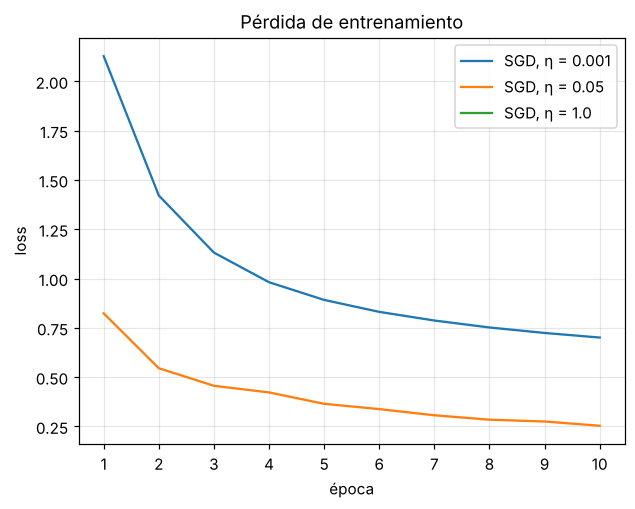

In [10]:
plot_curves({'SGD, η = 0.001': h_sgd_low, 'SGD, η = 0.05': h_sgd, 'SGD, η = 1.0': h_sgd_high}, title='Pérdida de entrenamiento')

Con $\eta=0.001$ baja, pero muy despacio. Con $\eta=1.0$, la pérdida es `nan` desde la primera época: los pasos son tan grandes que los pesos explotan, y por eso la curva ni siquiera aparece. Con $\eta=0.05$ entrena bien. **La tasa de aprendizaje es el primer hiperparámetro que se ajusta.**

## 2. Momentum
$v \leftarrow \beta v + \nabla_\theta J_\mathcal{B}$, $\;\theta \leftarrow \theta - \eta v$. **Cambia un argumento:** `momentum=0.9`.

In [11]:
model = new_model()
# Momentum en PyTorch: v_t = β v_{t−1} + g_t,  θ_{t+1} = θ_t − η v_t,  β = momentum
h_mom = fit(model, torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9))

época 10: loss 0.263 · val_loss 0.518 · val_acc 0.830 · 3.3 s


Con $\beta=0.9$, en una dirección constante la velocidad se acumula hasta $1/(1-\beta)=10$ veces el gradiente. Es decir, momentum también **multiplica el paso efectivo por 10**. Para comparar de forma justa, dividimos $\eta$ entre 10:

In [12]:
model = new_model()
# Paso efectivo η/(1 − β) = 0.005/0.1 = 0.05: el mismo que SGD con η = 0.05
h_mom_fair = fit(model, torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9))

época 10: loss 0.237 · val_loss 0.438 · val_acc 0.850 · 3.0 s


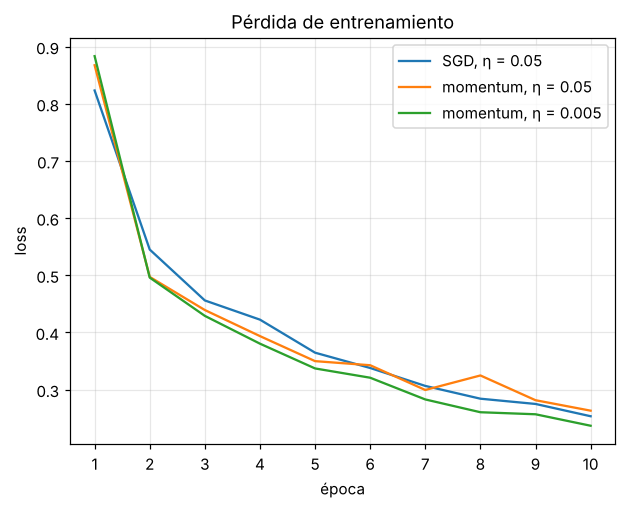

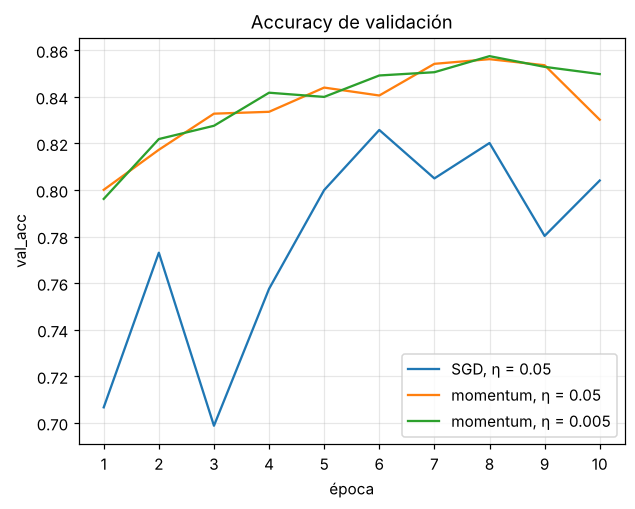

In [13]:
plot_curves({'SGD, η = 0.05': h_sgd, 'momentum, η = 0.05': h_mom, 'momentum, η = 0.005': h_mom_fair}, title='Pérdida de entrenamiento')
plot_curves({'SGD, η = 0.05': h_sgd, 'momentum, η = 0.05': h_mom, 'momentum, η = 0.005': h_mom_fair}, key='val_acc', title='Accuracy de validación')

Momentum con $\eta=0.005$ y SGD con $\eta=0.05$ dan pasos de tamaño parecido, pero momentum **promedia** las direcciones de lotes sucesivos. Por eso su accuracy de validación es mucho más estable (compárala con los saltos de SGD) y termina más alta.

## 3. Adam
Adam combina momentum con una escala **por parámetro**: divide cada componente del gradiente por la raíz de su segundo momento acumulado. **Cambia el optimizador.**

In [14]:
model = new_model()
# Adam: m_t = β₁ m_{t−1} + (1−β₁) g_t,   s_t = β₂ s_{t−1} + (1−β₂) g_t²
# θ_{t+1} = θ_t − η m̂_t / (√ŝ_t + ε),  con β₁ = 0.9, β₂ = 0.999: cada parámetro avanza ≈ η por paso
h_adam = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3))

época 10: loss 0.226 · val_loss 0.505 · val_acc 0.851 · 3.7 s


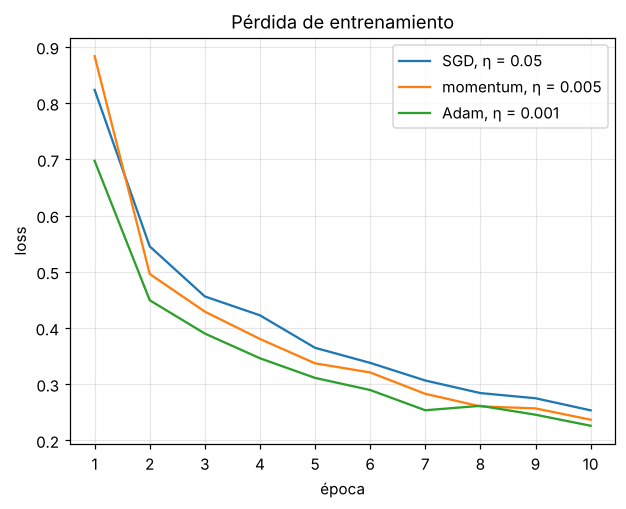

In [15]:
plot_curves({'SGD, η = 0.05': h_sgd, 'momentum, η = 0.005': h_mom_fair, 'Adam, η = 0.001': h_adam}, title='Pérdida de entrenamiento')

Adam arranca más rápido (mira la época 1) y funciona con su valor por defecto, $\eta=10^{-3}$, en muchos problemas. Por eso es el punto de partida habitual. Bien ajustado, SGD con momentum suele alcanzarlo, aunque cuesta más encontrar su $\eta$.

## 4. Tamaño de lote
**Cambia un argumento de `fit`:** `batch_size`. Con el mismo número de épocas, un lote pequeño da **más pasos** y uno grande da **menos pasos, cada uno menos ruidoso**.

In [16]:
# Cov(g_t) ≈ Cov_i(∇L_i)/|𝓑|: la std del ruido cae como 1/√|𝓑|   (diapositiva *Batch size controls the noise*)
for bs in [32, 128, 512]:
    print(f'batch_size = {bs:3d} → {math.ceil(len(X_train) / bs):3d} pasos por época')

batch_size =  32 → 313 pasos por época
batch_size = 128 →  79 pasos por época
batch_size = 512 →  20 pasos por época


In [17]:
model = new_model()
h_bs32 = fit(model, torch.optim.SGD(model.parameters(), lr=0.05), batch_size=32)

época 10: loss 0.187 · val_loss 0.432 · val_acc 0.856 · 5.5 s


In [18]:
model = new_model()
h_bs512 = fit(model, torch.optim.SGD(model.parameters(), lr=0.05), batch_size=512)

época 10: loss 0.400 · val_loss 0.467 · val_acc 0.828 · 1.9 s


Con lote 512 y el mismo $\eta$, el modelo da 4 veces menos pasos y avanza menos. La regla práctica es escalar $\eta$ junto con el lote:

In [19]:
model = new_model()
# lote ×4 → η ×4: con 4 veces menos pasos por época, cada paso debe avanzar más
h_bs512_lr = fit(model, torch.optim.SGD(model.parameters(), lr=0.2), batch_size=512)

época 10: loss 0.365 · val_loss 0.449 · val_acc 0.836 · 1.9 s


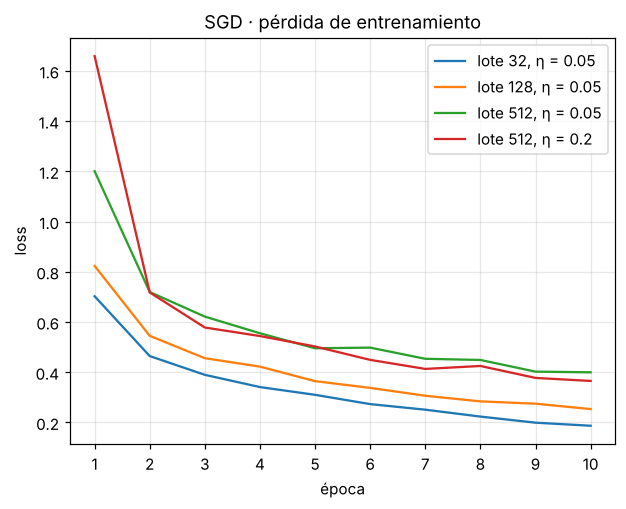

In [20]:
plot_curves({'lote 32, η = 0.05': h_bs32, 'lote 128, η = 0.05': h_sgd, 'lote 512, η = 0.05': h_bs512, 'lote 512, η = 0.2': h_bs512_lr},
            title='SGD · pérdida de entrenamiento')

Compara también los **tiempos** que imprimió cada corrida. El lote pequeño da los mejores números por época, pero tarda más porque procesa muchos lotes chicos. Elegir el tamaño de lote es buscar un equilibrio entre ruido, número de pasos y uso del hardware.

## 5. Warmup + coseno
Hasta ahora $\eta$ fue constante. Un **schedule** lo cambia en cada paso: empieza con un *warmup* lineal y luego decae siguiendo un coseno hasta casi cero.

**Cambia el loop:** `train_epoch` recibe un `scheduler` y llama a `scheduler.step()` después de cada `opt.step()`. Es la única línea nueva.

In [21]:
def train_epoch(model, opt, batch_size=128, scheduler=None):
    model.train()  # modo entrenamiento: Dropout activo, BatchNorm con estadísticas del lote
    perm = torch.randperm(len(X_train))  # orden nuevo en cada época → mini-lotes 𝓑_t distintos
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]  # índices del mini-lote 𝓑_t
        loss = loss_fn(model(X_train[b]), y_train[b])  # J_𝓑(θ) = (1/|𝓑|) Σ_{i∈𝓑} L_i(θ)
        # borrar g anterior · g_t = ∇_θ J_𝓑 (backprop) · θ ← regla del optimizador
        opt.zero_grad(); loss.backward(); opt.step()
        if scheduler is not None:
            scheduler.step()  # NUEVO: η_t = s(t) · η_0 cambia en cada paso
        total += loss.item() * len(b)  # promedio de la época ≈ J sobre entrenamiento
    return total / len(X_train)

def fit_scheduled(model, opt, scheduler, epochs=10, batch_size=128):
    hist = {'loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt, batch_size, scheduler))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_loss {val_loss:.3f} · val_acc {val_acc:.3f}")
    return hist

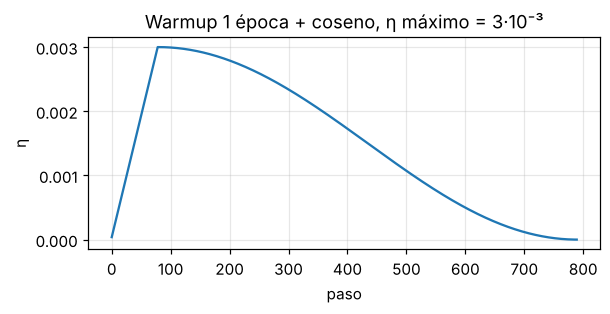

In [22]:
steps_per_epoch = math.ceil(len(X_train) / 128)
total_steps, warmup_steps = 10 * steps_per_epoch, steps_per_epoch      # 1 época de warmup

# s(t) en η_t = s(t) · η_0.  Warmup: s(t) = t/T_w.  Después: s(t) = ½ (1 + cos(π · progreso))
def warmup_cosine(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

plt.figure(figsize=(6, 2.5))
plt.plot([3e-3 * warmup_cosine(t) for t in range(total_steps)])
plt.xlabel('paso'); plt.ylabel('η'); plt.title('Warmup 1 época + coseno, η máximo = 3·10⁻³'); plt.show()

In [23]:
model = new_model()
h_adam_const = fit(model, torch.optim.Adam(model.parameters(), lr=3e-3))

época 10: loss 0.284 · val_loss 0.533 · val_acc 0.828 · 3.6 s


In [24]:
model = new_model()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
# η_t = η_0 · warmup_cosine(t) después de cada scheduler.step()
scheduler = torch.optim.lr_scheduler.LambdaLR(opt, warmup_cosine)
h_adam_cos = fit_scheduled(model, opt, scheduler)

época 10: loss 0.154 · val_loss 0.375 · val_acc 0.875


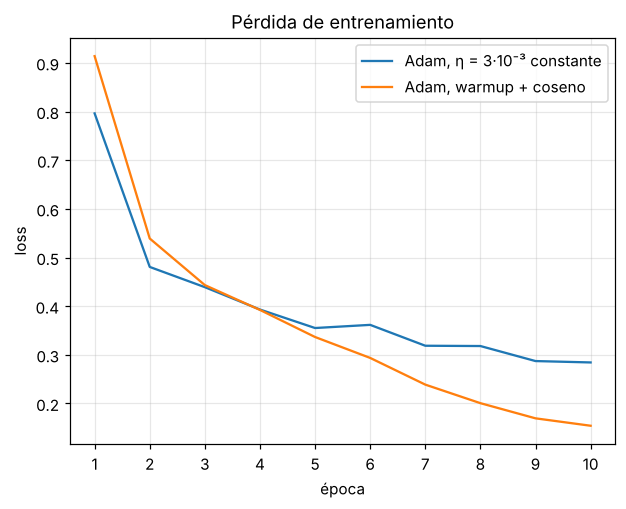

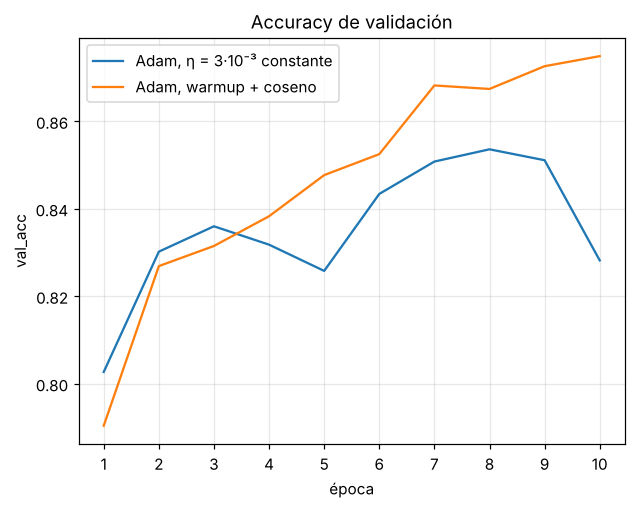

In [25]:
plot_curves({'Adam, η = 3·10⁻³ constante': h_adam_const, 'Adam, warmup + coseno': h_adam_cos}, title='Pérdida de entrenamiento')
plot_curves({'Adam, η = 3·10⁻³ constante': h_adam_const, 'Adam, warmup + coseno': h_adam_cos}, key='val_acc', title='Accuracy de validación')

Con el mismo $\eta$ máximo, el coseno da pasos grandes al principio, cuando hay mucho por aprender, y pasos pequeños al final, que es cuando hay que asentarse en un mínimo. El warmup evita que los primeros pasos, todavía con estadísticas de Adam poco confiables, desordenen la red.

## 6. Norma del gradiente y clipping
Ahora medimos $\lVert\nabla_\theta J_\mathcal{B}\rVert$ en cada paso. `clip_grad_norm_` hace dos cosas: **devuelve** la norma y, si supera `max_norm`, **reescala** el gradiente para que su norma sea exactamente `max_norm`, sin cambiar su dirección.

**Cambia el loop:** una línea entre `backward()` y `step()`.

In [26]:
def train_with_clipping(model, opt, epochs=10, batch_size=128, max_norm=float('inf')):
    hist = {'loss': [], 'val_loss': [], 'val_acc': [], 'grad_norm': []}
    for epoch in range(epochs):
        model.train(); perm = torch.randperm(len(X_train)); total = 0.0
        for i in range(0, len(X_train), batch_size):
            b = perm[i:i + batch_size]
            loss = loss_fn(model(X_train[b]), y_train[b])
            opt.zero_grad(); loss.backward()  # g_t = ∇_θ J_𝓑, todavía sin aplicar
            # NUEVO: devuelve ‖g_t‖ y hace g_t ← g_t · min(1, max_norm/‖g_t‖)
            norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            hist['grad_norm'].append(norm.item())
            opt.step(); total += loss.item() * len(b)  # el paso usa el gradiente ya recortado
        hist['loss'].append(total / len(X_train))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_acc {val_acc:.3f} · norma máxima {max(hist['grad_norm']):.3g}")
    return hist

Usamos un momentum demasiado agresivo a propósito: $\eta=0.3$ con $\beta=0.9$ equivale a un paso efectivo de 3.

In [27]:
model = new_model()
# paso efectivo η/(1 − β) = 0.3/0.1 = 3: demasiado grande para esta red
h_noclip = train_with_clipping(model, torch.optim.SGD(model.parameters(), lr=0.3, momentum=0.9))

época 10: loss nan · val_acc 0.101 · norma máxima inf


In [28]:
model = new_model()
h_clip = train_with_clipping(model, torch.optim.SGD(model.parameters(), lr=0.3, momentum=0.9), max_norm=1.0)

época 10: loss 0.557 · val_acc 0.726 · norma máxima 9.23


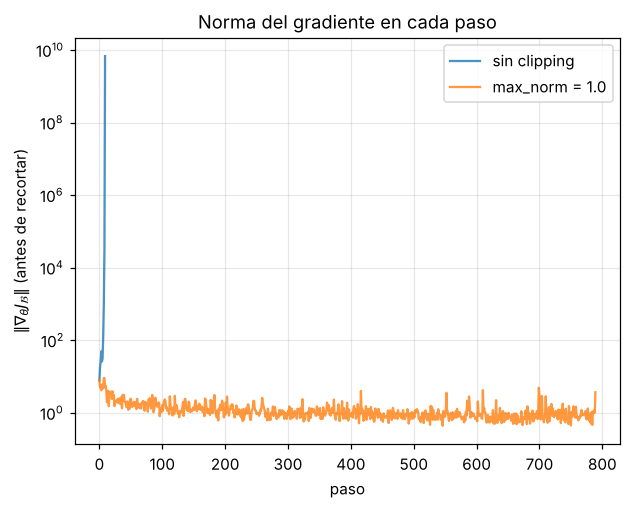

In [29]:
plt.plot(h_noclip['grad_norm'], label='sin clipping', alpha=0.8)
plt.plot(h_clip['grad_norm'], label='max_norm = 1.0', alpha=0.8)
plt.yscale('log'); plt.xlabel('paso'); plt.ylabel(r'$\|\nabla_\theta J_\mathcal{B}\|$ (antes de recortar)')
plt.title('Norma del gradiente en cada paso'); plt.legend(); plt.show()

Sin clipping, la norma explota en los primeros pasos, llega a `inf` y desde ahí todo es `nan`, por eso la curva se corta. Con clipping, los pasos quedan acotados y el entrenamiento sobrevive. Ojo: el clipping **no reemplaza** un buen $\eta$; solo evita que unos pocos pasos malos destruyan la red. Con $\eta=0.1$ la misma red no lo necesita (experimento 4).

Medir la norma del gradiente cuesta una línea, y en la curva se nota antes de que la pérdida llegue a `nan`. Vale la pena registrarla siempre.

## Resumen

In [30]:
runs = {'SGD, η = 0.05': h_sgd, 'momentum, η = 0.005': h_mom_fair, 'Adam, η = 0.001': h_adam,
        'SGD, lote 512, η = 0.2': h_bs512_lr, 'Adam, warmup + coseno': h_adam_cos, 'momentum η = 0.3 + clipping': h_clip}
for name, h in runs.items():
    print(f"{name:28s} loss final {h['loss'][-1]:.3f} · val_acc final {h['val_acc'][-1]:.3f}")

SGD, η = 0.05                loss final 0.253 · val_acc final 0.804
momentum, η = 0.005          loss final 0.237 · val_acc final 0.850
Adam, η = 0.001              loss final 0.226 · val_acc final 0.851
SGD, lote 512, η = 0.2       loss final 0.365 · val_acc final 0.836
Adam, warmup + coseno        loss final 0.154 · val_acc final 0.875
momentum η = 0.3 + clipping  loss final 0.557 · val_acc final 0.726


## Tu turno · 10 minutos
Copia una celda, cambia **una** cosa y superpón la curva nueva con `plot_curves`.

1. Busca el $\eta$ más grande con el que SGD sin momentum todavía entrena. Prueba 0.1, 0.2 y 0.5.
2. Repite la sección 3 con `torch.optim.Adam(..., lr=1e-2)` y luego con `1e-4`. ¿Es Adam tan insensible a $\eta$ como se dice?
3. En la sección 5, quita el warmup (`warmup_steps = 0`; ajusta `warmup_cosine` para que no divida por cero). ¿Cambia la primera época?
4. Repite la sección 6 con $\eta=0.1$ con y sin clipping. ¿Hace falta recortar?
5. En la sección 4, mide cuántos **pasos** necesita cada tamaño de lote para llegar a una pérdida de 0.4. ¿Y cuántos **segundos**?

**Para pensar.** Tienes un presupuesto de 5 minutos de GPU. ¿Qué tamaño de lote y qué schedule eliges, y qué curva miras para saber si $\eta$ es demasiado grande?

In [31]:
# Experimento 1: el η más grande con el que SGD todavía entrena


### Referencias
- Sutskever, Martens, Dahl y Hinton (2013), *On the importance of initialization and momentum in deep learning*, ICML.
- Kingma y Ba (2015), *Adam: A Method for Stochastic Optimization*, ICLR · Loshchilov y Hutter (2017), *SGDR: Stochastic Gradient Descent with Warm Restarts*, ICLR.
- Goyal et al. (2017), *Accurate, Large Minibatch SGD* (escalar η con el lote y warmup) · Pascanu, Mikolov y Bengio (2013), *On the difficulty of training recurrent neural networks* (clipping).
- [PyTorch · `torch.optim`](https://docs.pytorch.org/docs/stable/optim.html) y [`clip_grad_norm_`](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html).